### Mount Google Drive

To access files from Google Drive, you first need to mount it. Running the following cell will prompt you to authenticate with your Google account.

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
import pandas as pd

file_path = '/content/drive/My Drive/424 Project/Bengali_Banglish_80K_Dataset.csv'
df = pd.read_csv(file_path)

display(df.head(7))

,Bengali,Label,Banglish
0,এখানে কাওকে কবর দিয়ো না তাহলে তোমাদের পরিবারের...,fear,ekhane kaoke kobor diyo na tahole tomader pori...
1,কিন্ত ভয় কিসের থেকে আমি জানতামনা কিন্ত আমার মন...,fear,kinto voy kiser theke ami jantamna kinto amar ...
2,করোনাভাইরাস থেকে সৃষ্ট রোগ কভিড১৯ বিশ্বব্যাপী ...,fear,kronavairas theke srishto rog covid 19 bishbob...
3,চিতাও তার দিকে এগোতে সাহস পাচ্ছে না দুদিনের অন...,fear,citao tar dike egote sahosh pacche na dudiner ...
4,রানী মেরি টিউডরের প্রেতাত্মা এটাআজ চেষ্টা করলা...,fear,rani meri tiudrer pretatma etaaj ceshta korlam...
5,নিত্যপ্রয়োজনীয় জিনিসগুলো নিয়ে একটু দুশ্চিন্তার...,fear,nitjopryojniy jinisgulo niye ektu dushcintar k...
6,গতবছরের ৩১ ডিসেম্বর এই শহরে নিউমোনিয়ার মতো এক...,fear,gotobochrer 31 December ei shohore niumoniyar ...


In [47]:
import difflib

# Get all unique words from the vocabulary we built
all_words = vocab_df['Word'].astype(str).tolist()

# Target specific emotional/action words to find variants in the long tail
target_words = ['bhalo', 'bhalobashi', 'kosto', 'bhoy', 'khushi', 'ekhon', 'ami', 'amar']

potential_variants = {}

print("Searching for variants of target emotional words...")
for target in target_words:
    # get_close_matches uses a Ratcliff/Obershelp-style algorithm, much faster than nested loops
    matches = difflib.get_close_matches(target, all_words, n=10, cutoff=0.8)
    potential_variants[target] = [m for m in matches if m != target]

for target, matches in potential_variants.items():
    print(f"Target: {target} -> Potential Variants: {matches}")

Searching for variants of target emotional words...
Target: bhalo -> Potential Variants: ['bhal', 'balo', 'bujhalo', 'bojhalo', 'bachalo', 'tbhao', 'khalo', 'jbalo', 'hjalo', 'harlo']
Target: bhalobashi -> Potential Variants: ['balobasi', 'valobashi', 'balbasi', 'valobaschi']
Target: kosto -> Potential Variants: ['kostho', 'koshto', 'osto', 'koto', 'rikosto', 'okoshto', 'koyesto', 'koshtto', 'koshtho']
Target: bhoy -> Potential Variants: ['hoy', 'boy', 'bodhoy', 'bishoy']
Target: khushi -> Potential Variants: ['okhushi', 'khushi৷', 'khushir', 'khushii', 'khusi', 'khush', 'khshi', 'khushi৷৷', 'khushite']
Target: ekhon -> Potential Variants: ['ლekhon', 'ekohon', 'ekhon৷', 'ekhono', 'ekhoni', 'dekhon', 'bekhon', 'khon', 'ekon']
Target: ami -> Potential Variants: ['tami', 'sami', 'oami', 'nami', 'mami', 'kami', 'iami', 'hami', 'gami']
Target: amar -> Potential Variants: ['৷amar', 'tamar', 'samar', 'oamar', 'namar', 'mamar', 'kamar', 'jamar', 'hamar']


In [48]:
import re

def safe_normalize(text, canonical_dict):
    if not isinstance(text, str):
        return text

    # Use word boundaries to replace variants while preserving surrounding context/punctuation
    for variant, canonical in canonical_dict.items():
        pattern = re.compile(r'\b' + re.escape(variant) + r'\b', re.IGNORECASE)
        text = pattern.sub(canonical, text)
    return text

# Updated Canonical Dictionary based on manual review and phonetic mapping
canonical_dict = {
    'valo': 'bhalo',
    'vhalo': 'bhalo',
    'voy': 'bhoy',
    'bhoi': 'bhoy',
    'akhon': 'ekhon',
    'amin': 'ami',
    'valoi': 'bhalo',
    'val': 'bhalo'
}

# Apply safe normalization to the original Banglish column
df_banglish['Banglish_Clean'] = df_banglish['Banglish'].apply(lambda x: safe_normalize(x, canonical_dict))

print("Safe normalization complete. Punctuation and casing preserved.")
display(df_banglish[['Banglish', 'Banglish_Clean']].head(10))

Safe normalization complete. Punctuation and casing preserved.


,Banglish,Banglish_Clean
0,ekhane kaoke kobor diyo na tahole tomader pori...,ekhane kaoke kobor diyo na tahole tomader pori...
1,kinto voy kiser theke ami jantamna kinto amar ...,kinto bhoy kiser theke ami jantamna kinto amar...
2,kronavairas theke srishto rog covid 19 bishbob...,kronavairas theke srishto rog covid 19 bishbob...
3,citao tar dike egote sahosh pacche na dudiner ...,citao tar dike egote sahosh pacche na dudiner ...
4,rani meri tiudrer pretatma etaaj ceshta korlam...,rani meri tiudrer pretatma etaaj ceshta korlam...
5,nitjopryojniy jinisgulo niye ektu dushcintar k...,nitjopryojniy jinisgulo niye ektu dushcintar k...
6,gotobochrer 31 December ei shohore niumoniyar ...,gotobochrer 31 December ei shohore niumoniyar ...
7,strir phone risiv kore shonen tini bolchen tom...,strir phone risiv kore shonen tini bolchen tom...
8,vinno dhoroner sontrasi hamla notun kore udbeg...,vinno dhoroner sontrasi hamla notun kore udbeg...
9,ami oke khabar khawar koyekbar dekechi o shone...,ami oke khabar khawar koyekbar dekechi o shone...


In [49]:
from collections import Counter
import re

# Ensure we have the banglish dataframe cleaned of nulls as per previous context
df_banglish = df[['Banglish', 'Label']].dropna().copy()

def get_vocabulary(series):
    words = []
    for text in series:
        # Simple tokenization: lowercase and remove non-alphanumeric characters
        tokens = re.findall(r'\w+', str(text).lower())
        words.extend(tokens)
    return Counter(words)

vocab_counts = get_vocabulary(df_banglish['Banglish'])

print(f"Total unique words found: {len(vocab_counts)}")
print("Top 20 most frequent words:")
for word, count in vocab_counts.most_common(20):
    print(f"{word}: {count}")

# Convert to dataframe for easier manipulation in next steps
vocab_df = pd.DataFrame(vocab_counts.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)
display(vocab_df.head(10))

Total unique words found: 81460
Top 20 most frequent words:
na: 26141
ei: 15456
ami: 15196
kore: 15104
amar: 12692
ar: 12155
ki: 10889
jonjo: 8443
tar: 8185
onek: 8057
hoy: 8022
je: 7876
o: 6982
valo: 6928
theke: 6902
hobe: 6443
kotha: 6404
ta: 6244
ekta: 6056
ke: 5977


,Word,Frequency
4,na,26141
108,ei,15456
27,ami,15196
131,kore,15104
29,amar,12692
8,ar,12155
275,ki,10889
36,jonjo,8443
33,tar,8185
38,onek,8057


In [50]:
# Refined Canonical Dictionary from targeted search results
refined_canonical_dict = {
    'valo': 'bhalo',
    'vhalo': 'bhalo',
    'val': 'bhalo',
    'balobasi': 'bhalobashi',
    'valobashi': 'bhalobashi',
    'balbasi': 'bhalobashi',
    'valobaschi': 'bhalobashi',
    'kostho': 'kosto',
    'koshto': 'kosto',
    'koshtto': 'kosto',
    'voy': 'bhoy',
    'bhoi': 'bhoy',
    'khusi': 'khushi',
    'khush': 'khushi',
    'akhon': 'ekhon',
    'ekon': 'ekhon',
    'amin': 'ami',
    'amaro': 'amar'
}

# Re-apply safe normalization with the expanded dictionary
df_banglish['Banglish_Clean'] = df_banglish['Banglish'].apply(lambda x: safe_normalize(x, refined_canonical_dict))

# Save the improved dataset
df_banglish.to_csv('banglish_normalized_v2.csv', index=False)

print("Refined safe normalization complete. Dataset saved as 'banglish_normalized_v2.csv'.")
display(df_banglish[['Banglish', 'Banglish_Clean']].iloc[10:20])

Refined safe normalization complete. Dataset saved as 'banglish_normalized_v2.csv'.


,Banglish,Banglish_Clean
10,apnio to ekjon manush apnar voy korche hja voy...,apnio to ekjon manush apnar bhoy korche hja bh...
11,2015 saler marco theke songghate jorjor hoye a...,2015 saler marco theke songghate jorjor hoye a...
12,tar koyekdin porei barita uttor dike samanjo h...,tar koyekdin porei barita uttor dike samanjo h...
13,je kono somoye ami dhorshit hote pari shei voy,je kono somoye ami dhorshit hote pari shei bhoy
14,otosklerosiser cikitsa ki ekhon porjonto emon ...,otosklerosiser cikitsa ki ekhon porjonto emon ...
15,birokti ar klanti ebar kichuta voye porinot ho...,birokti ar klanti ebar kichuta voye porinot ho...
16,ami gele amader barite ar keu thakar moto tha...,ami gele amader barite ar keu thakar moto tha...
17,dirghdin dhore bishbe poshak roptanite ditio o...,dirghdin dhore bishbe poshak roptanite ditio o...
18,shot ceshta thakar sottbeo ei atongkit poristh...,shot ceshta thakar sottbeo ei atongkit poristh...
19,ami ter pelam dorodor kore ghamchi shirdara di...,ami ter pelam dorodor kore ghamchi shirdara di...


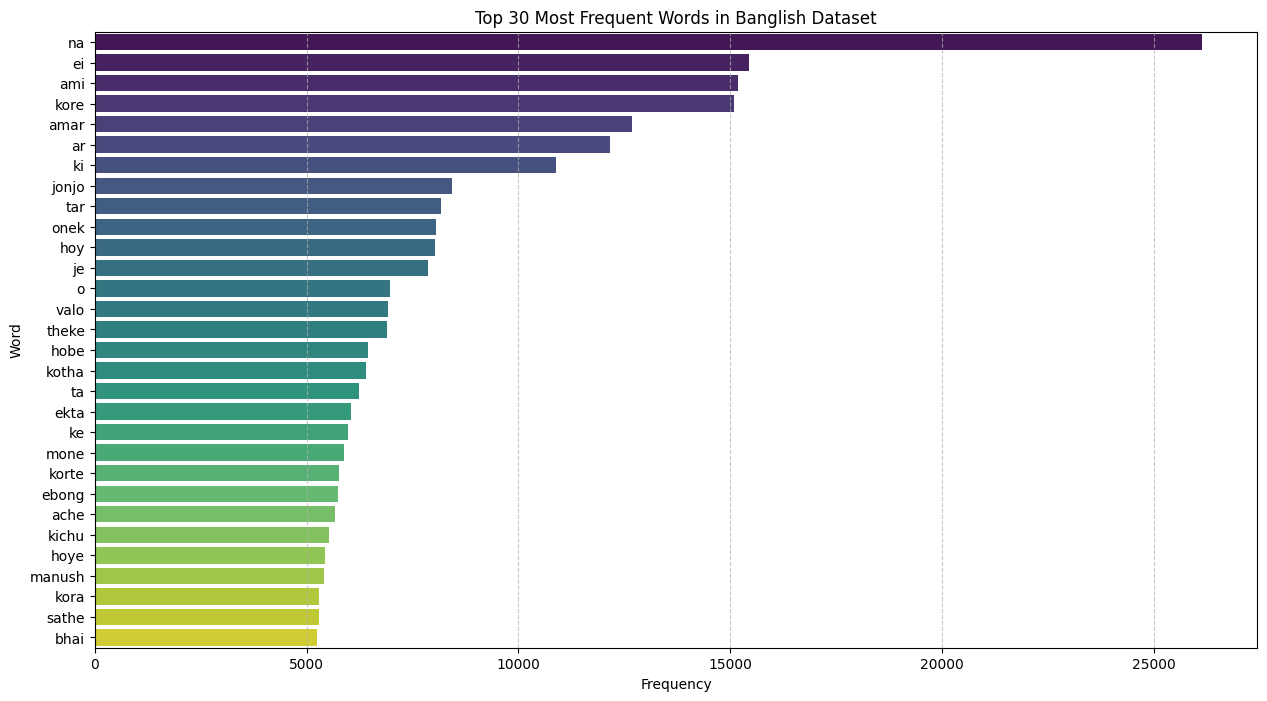

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select top 30 words for visualization
top_n = 30
top_words = vocab_df.head(top_n)

plt.figure(figsize=(15, 8))
# Updated palette usage to avoid FutureWarning
sns.barplot(data=top_words, x='Frequency', y='Word', hue='Word', palette='viridis', legend=False)
plt.title(f'Top {top_n} Most Frequent Words in Banglish Dataset')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [52]:
# 1. Bring back the native Bengali column matching our cleaned Banglish
# We use the original 'df' index to align perfectly with 'df_banglish'
df_banglish['Bengali'] = df.loc[df_banglish.index, 'Bengali']

# Ensure no nulls sneaked in
df_banglish = df_banglish.dropna(subset=['Bengali']).copy()

print(f"Dataset shape ready for Lexicon Engineering: {df_banglish.shape}")
display(df_banglish[['Bengali', 'Banglish_Clean', 'Label']].head(3))

Dataset shape ready for Lexicon Engineering: (80094, 4)


,Bengali,Banglish_Clean,Label
0,এখানে কাওকে কবর দিয়ো না তাহলে তোমাদের পরিবারের...,ekhane kaoke kobor diyo na tahole tomader pori...,fear
1,কিন্ত ভয় কিসের থেকে আমি জানতামনা কিন্ত আমার মন...,kinto bhoy kiser theke ami jantamna kinto amar...,fear
2,করোনাভাইরাস থেকে সৃষ্ট রোগ কভিড১৯ বিশ্বব্যাপী ...,kronavairas theke srishto rog covid 19 bishbob...,fear


In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
import numpy as np

print("Building Native Bengali Emotion Lexicon Model...")

# 1. Build the Native Lexicon Pipeline (TF-IDF + Naive Bayes)
# We use character and word n-grams to capture Bengali morphological roots
lexicon_model = make_pipeline(
    TfidfVectorizer(analyzer='word', ngram_range=(1, 3), max_features=15000),
    MultinomialNB()
)

# 2. Train it strictly on the native Bengali text
lexicon_model.fit(df_banglish['Bengali'], df_banglish['Label'])

# 3. Extract the 'Cheat Sheet' probability scores for all 80k rows
print("Extracting 6-dimensional emotion features...")
emotion_probabilities = lexicon_model.predict_proba(df_banglish['Bengali'])

# 4. Create the new numerical feature columns in our main dataframe
classes = lexicon_model.classes_  # Should be: anger, disgust, fear, joy, sadness, surprise
for i, emotion in enumerate(classes):
    df_banglish[f'lexicon_{emotion}'] = emotion_probabilities[:, i]

# 5. Save the fully prepped dataset for PyTorch
df_banglish.to_csv('banglish_features_ready.csv', index=False)

print("\nPhase 2 Complete! Lexicon features successfully fused to Banglish text.")
# Display the Banglish text alongside its new mathematical cheat sheet
display(df_banglish[['Banglish_Clean', 'Label', 'lexicon_fear', 'lexicon_joy', 'lexicon_anger']].head(5))

Building Native Bengali Emotion Lexicon Model...
Extracting 6-dimensional emotion features...

Phase 2 Complete! Lexicon features successfully fused to Banglish text.


,Banglish_Clean,Label,lexicon_fear,lexicon_joy,lexicon_anger
0,ekhane kaoke kobor diyo na tahole tomader pori...,fear,0.064242,0.062511,0.235373
1,kinto bhoy kiser theke ami jantamna kinto amar...,fear,0.404888,0.148687,0.121254
2,kronavairas theke srishto rog covid 19 bishbob...,fear,0.496631,0.146183,0.041247
3,citao tar dike egote sahosh pacche na dudiner ...,fear,0.160232,0.178181,0.207096
4,rani meri tiudrer pretatma etaaj ceshta korlam...,fear,0.752271,0.056475,0.041373


In [54]:
from sklearn.model_selection import train_test_split

print("Finalizing Dataset for PyTorch...")

# 1. Encode the target labels to integers (0 to 5)
label_mapping = {
    'anger': 0,
    'disgust': 1,
    'fear': 2,
    'joy': 3,
    'sadness': 4,
    'surprise': 5
}
df_banglish['label_id'] = df_banglish['Label'].map(label_mapping)

# Ensure no mapping errors occurred
assert df_banglish['label_id'].isnull().sum() == 0, "Error: Some labels didn't map correctly!"

# 2. Define our feature columns (Text + 6 Lexicon Probabilities)
feature_cols = [
    'Banglish_Clean', 'label_id',
    'lexicon_anger', 'lexicon_disgust', 'lexicon_fear',
    'lexicon_joy', 'lexicon_sadness', 'lexicon_surprise'
]
df_final = df_banglish[feature_cols].copy()

# 3. Stratified Train/Val/Test Split (80% Train, 10% Val, 10% Test)
# Stratification ensures the class imbalance (more joy than fear) is perfectly mirrored in all splits
train_df, temp_df = train_test_split(df_final, test_size=0.20, stratify=df_final['label_id'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label_id'], random_state=42)

print(f"Training set: {train_df.shape[0]} rows")
print(f"Validation set: {val_df.shape[0]} rows")
print(f"Testing set: {test_df.shape[0]} rows")

# 4. Save the final splits to disk
train_df.to_csv('train_split.csv', index=False)
val_df.to_csv('val_split.csv', index=False)
test_df.to_csv('test_split.csv', index=False)

print("\nData Pipeline 100% Complete. Ready for Model Training.")

Finalizing Dataset for PyTorch...
Training set: 64075 rows
Validation set: 8009 rows
Testing set: 8010 rows

Data Pipeline 100% Complete. Ready for Model Training.


In [55]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
import pandas as pd

# Load the tokenizer
model_name = "csebuetnlp/banglabert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class BanglishLexiconDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.texts = dataframe['Banglish_Clean'].astype(str).values
        self.labels = dataframe['label_id'].values
        # Extract the 6 lexicon columns
        self.lexicon_features = dataframe[['lexicon_anger', 'lexicon_disgust', 'lexicon_fear',
                                           'lexicon_joy', 'lexicon_sadness', 'lexicon_surprise']].values
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        lex_feats = self.lexicon_features[idx]

        # Tokenize the text
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'lexicon_features': torch.tensor(lex_feats, dtype=torch.float),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create the datasets
train_dataset = BanglishLexiconDataset(train_df, tokenizer)
val_dataset = BanglishLexiconDataset(val_df, tokenizer)

# HIGH-PERFORMANCE DATALOADERS (Batch size 32, 2 workers, pinned memory)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("High-Performance DataLoaders initialized!")

High-Performance DataLoaders initialized!


In [56]:
import torch.nn as nn
import torch
from transformers import AutoModel

class LexiconAugmentedBERT(nn.Module):
    def __init__(self, model_name, num_classes=6, lexicon_size=6):
        super(LexiconAugmentedBERT, self).__init__()

        # 1. Load the pre-trained BERT body
        self.bert = AutoModel.from_pretrained(model_name)

        # 2. Dropout for regularization
        self.dropout = nn.Dropout(0.3)

        # 3. The Custom Classification Head (768 + 6 = 774)
        self.classifier = nn.Linear(self.bert.config.hidden_size + lexicon_size, num_classes)

    def forward(self, input_ids, attention_mask, lexicon_features):
        # Get the text embeddings from BERT
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        # THE FIX: Manually extract the [CLS] token (0th index) from the last_hidden_state
        # because ELECTRA architectures do not generate a 'pooler_output'
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)

        # CONCATENATION: Combine BERT features with Lexicon Cheat Sheet
        combined_features = torch.cat((pooled_output, lexicon_features), dim=1)

        # Final emotion prediction
        logits = self.classifier(combined_features)

        return logits

# Initialize the model and move it to the GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LexiconAugmentedBERT(model_name).to(device)

print(f"Model architecture built (with ELECTRA fix) and moved to: {device}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraModel LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
electra.embeddings.position_ids                   | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model architecture built (with ELECTRA fix) and moved to: cuda


In [57]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super(FocalLoss, self).__init__()
        # Alpha holds the class weights. Gamma is the focusing parameter.
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        # Calculate standard cross entropy
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        # Calculate the probability of the correct class
        pt = torch.exp(-ce_loss)
        # Apply the focal weight
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        return focal_loss.mean()

# Calculate class weights inversely proportional to their frequency to pass into Alpha
class_counts = train_df['label_id'].value_counts().sort_index().values
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum() * 6.0 # Normalize
class_weights = class_weights.to(device)

# Initialize our custom loss function
criterion = FocalLoss(alpha=class_weights, gamma=2)

print("Focal Loss initialized with calculated class weights!")


Focal Loss initialized with calculated class weights!


In [58]:
import torch
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, accuracy_score
from tqdm.auto import tqdm
import torch.cuda.amp as amp
import numpy as np

EPOCHS = 3
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# Initialize the GradScaler for Mixed Precision Training
scaler = amp.GradScaler()

def train_epoch(model, dataloader, criterion, optimizer, device, scheduler):
    model.train()
    total_loss = 0

    progress_bar = tqdm(dataloader, desc="Training (AMP Enabled)")
    for batch in progress_bar:
        # non_blocking=True allows asynchronous memory transfer
        input_ids = batch['input_ids'].to(device, non_blocking=True)
        attention_mask = batch['attention_mask'].to(device, non_blocking=True)
        lexicon_features = batch['lexicon_features'].to(device, non_blocking=True)
        labels = batch['labels'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True) # Slightly faster than standard zero_grad

        # Enable Automatic Mixed Precision for the forward pass
        with amp.autocast():
            logits = model(input_ids, attention_mask, lexicon_features)
            loss = criterion(logits, labels)

        # Backward pass using the scaler
        scaler.scale(loss).backward()

        # Unscale before clipping to ensure gradients aren't distorted
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Step optimizer and update scaler
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    return total_loss / len(dataloader)

def eval_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    predictions, true_labels = [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            lexicon_features = batch['lexicon_features'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)

            # Use AMP in evaluation for faster inference
            with amp.autocast():
                logits = model(input_ids, attention_mask, lexicon_features)
                loss = criterion(logits, labels)

            total_loss += loss.item()
            _, preds = torch.max(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(true_labels, predictions)
    val_f1 = f1_score(true_labels, predictions, average='weighted')

    return total_loss / len(dataloader), val_acc, val_f1

print("🚀 Starting High-Performance Training Process...")
best_f1 = 0

for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch + 1}/{EPOCHS} ---")

    train_loss = train_epoch(model, train_loader, criterion, optimizer, device, scheduler)
    val_loss, val_acc, val_f1 = eval_model(model, val_loader, criterion, device)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Weighted F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), 'banglish_lexicon_bert_best.pt')
        print("🌟 New best model saved! 🌟")

🚀 Starting High-Performance Training Process...

--- Epoch 1/3 ---


/tmp/ipykernel_36679/3807557757.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()


Training (AMP Enabled):   0%|          | 0/2003 [00:00<?, ?it/s]

/tmp/ipykernel_36679/3807557757.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_36679/3807557757.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Train Loss: 0.6602
Val Loss: 0.5771 | Val Acc: 0.5579 | Val Weighted F1: 0.5593
🌟 New best model saved! 🌟

--- Epoch 2/3 ---


...

/tmp/ipykernel_36679/3807557757.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_36679/3807557757.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Train Loss: 0.4908
Val Loss: 0.5283 | Val Acc: 0.5986 | Val Weighted F1: 0.5983
🌟 New best model saved! 🌟

--- Epoch 3/3 ---


Training (AMP Enabled):   0%|          | 0/2003 [00:00<?, ?it/s]

/tmp/ipykernel_36679/3807557757.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_36679/3807557757.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Train Loss: 0.3990
Val Loss: 0.5323 | Val Acc: 0.6129 | Val Weighted F1: 0.6150
🌟 New best model saved! 🌟
